# 05.04 - Model Evaluation & Metrics

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

How do we know if a model is good? Evaluation metrics tell us. Different problems need different metrics — accuracy is useless on imbalanced data, and MSE tells you nothing about classification.

## 2. Why Does This Matter?

A model without evaluation is a guess. Metrics let you compare models, detect overfitting, and choose the right threshold for your business problem.

## 3. Prerequisites

- 05.01-05.03: ML fundamentals, linear/logistic regression

## 4. Learning Objectives

- Compute accuracy, precision, recall, F1, ROC-AUC for classification
- Compute MAE, MSE, RMSE, R² for regression
- Choose the right metric for your problem
- Understand calibration and threshold effects

## 5. Mental Model

Metrics answer: "How wrong is my model, and in what way?"
- Classification: predict categories → use accuracy, precision, recall, F1, AUC
- Regression: predict numbers → use MAE, MSE, RMSE, R²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, average_precision_score, log_loss
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Classification Metrics

### Accuracy
Accuracy = (TP + TN) / (TP + TN + FP + FN)

Simple but misleading on imbalanced data. 99% accuracy is meaningless if 99% of samples are one class.

### Precision
Precision = TP / (TP + FP)

"How many of the predicted positives are actually positive?" High precision = few false alarms.

### Recall (Sensitivity)
Recall = TP / (TP + FN)

"How many of the actual positives did we catch?" High recall = few missed positives.

### F1 Score
F1 = 2 * (Precision * Recall) / (Precision + Recall)

Harmonic mean of precision and recall. Balances both concerns.

In [2]:
# Load breast cancer dataset for classification
bc = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=42, stratify=bc.target
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("=== Classification Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Log Loss:  {log_loss(y_test, y_proba):.4f}")

=== Classification Metrics ===
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861
ROC AUC:   0.9954
Log Loss:  0.0777


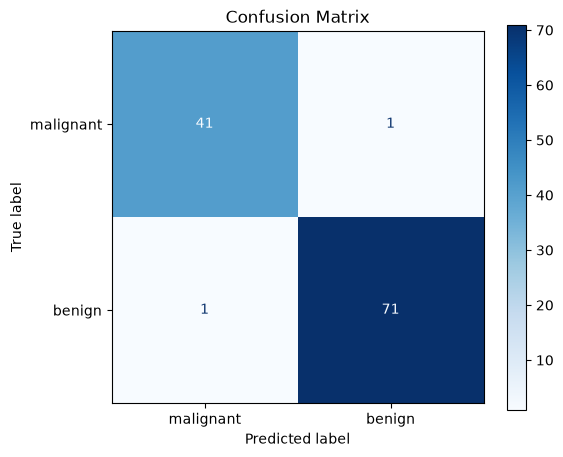

TN=41, FP=1, FN=1, TP=71


In [3]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=bc.target_names).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("TN={0}, FP={1}, FN={2}, TP={3}".format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

## 7. ROC Curve & AUC

The ROC curve plots True Positive Rate vs False Positive Rate at every threshold.
- AUC = 1.0: perfect classifier
- AUC = 0.5: random guessing
- AUC < 0.5: worse than random

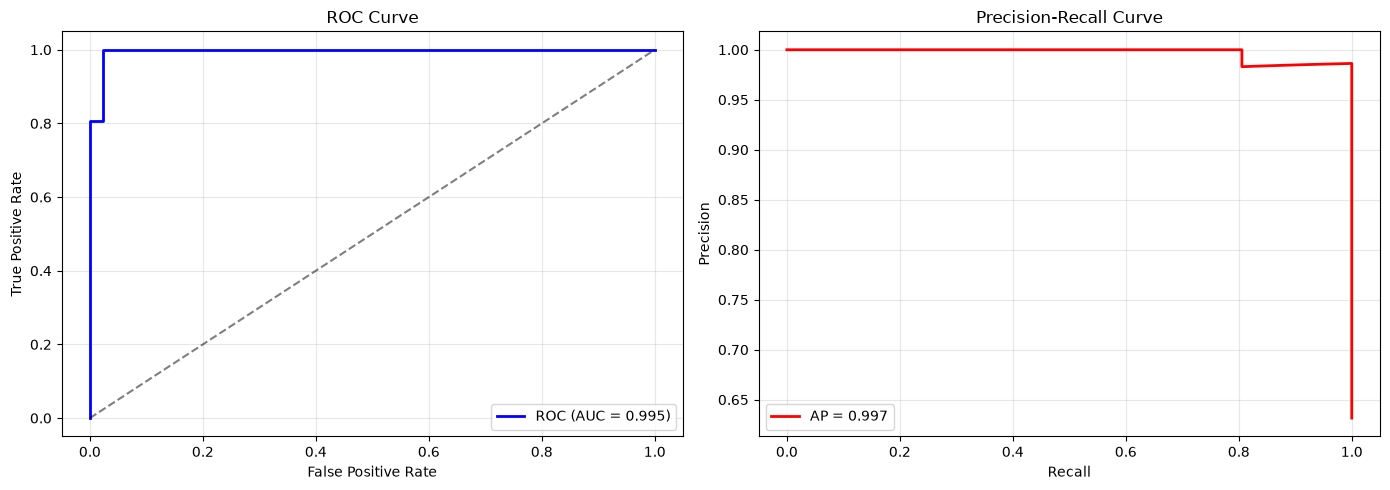

ROC AUC: 0.9954, Average Precision: 0.9971


In [4]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

axes[1].plot(recall_curve, precision_curve, 'r-', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"ROC AUC: {auc:.4f}, Average Precision: {ap:.4f}")

## 8. When to Use Which Metric

| Scenario | Best Metric | Why |
|----------|-------------|-----|
| Balanced classes | Accuracy | All errors equally costly |
| Imbalanced classes | F1, AUC, Precision, Recall | Accuracy is misleading |
| Cost of false positive high | Precision | Minimize false alarms |
| Cost of false negative high | Recall | Minimize missed detections |
| Need ranked predictions | AUC | Quality of probability estimates |
| Medical diagnosis | Recall + Precision | Must catch all cases, but also precise |

In [5]:
# Demonstrate accuracy paradox with imbalanced data
np.random.seed(42)
n = 1000
# 95% class 0, 5% class 1
y_imbalanced = np.array([0] * 950 + [1] * 50)
# "Model" that always predicts 0
y_pred_dumb = np.zeros(1000, dtype=int)

print("=== Accuracy Paradox ===")
print(f"Class distribution: {np.bincount(y_imbalanced)}")
print(f"Dumb model accuracy: {accuracy_score(y_imbalanced, y_pred_dumb):.2%}")
print(f"(It just predicts majority class!)")
print(f"\nF1 Score: {f1_score(y_imbalanced, y_pred_dumb, zero_division=0):.4f}")
print(f"(F1 correctly identifies this as useless)")

=== Accuracy Paradox ===
Class distribution: [950  50]
Dumb model accuracy: 95.00%
(It just predicts majority class!)

F1 Score: 0.0000
(F1 correctly identifies this as useless)


## 9. Regression Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(abs(y - y_hat)) | Average absolute error (same units as target) |
| **MSE** | mean((y - y_hat)²) | Penalizes large errors quadratically |
| **RMSE** | sqrt(MSE) | Same units as target, penalizes large errors |
| **R²** | 1 - SS_res/SS_tot | Proportion of variance explained (1 = perfect) |
| **MAPE** | mean(abs((y-y_hat)/y)) * 100 | Percentage error (intuitive) |

=== Regression Metrics ===
MAE:  42.79
MSE:  2900.19
RMSE: 53.85
R²:   0.4526


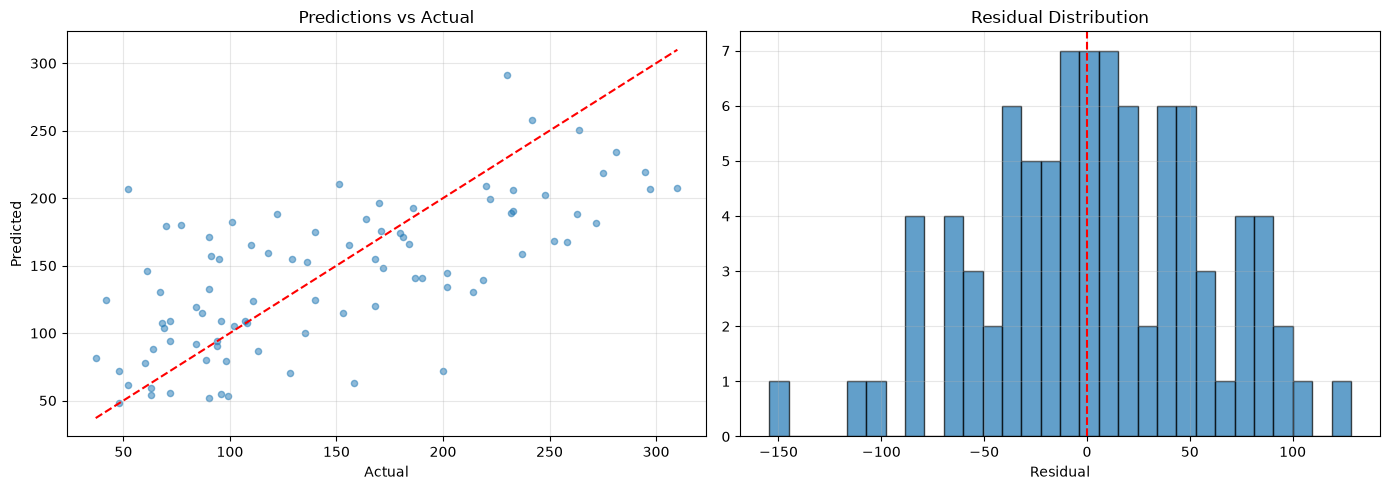

In [6]:
# Regression metrics on diabetes dataset
diabetes = load_diabetes()
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

print("=== Regression Metrics ===")
print(f"MAE:  {mean_absolute_error(y_test_r, y_pred_r):.2f}")
print(f"MSE:  {mean_squared_error(y_test_r, y_pred_r):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
print(f"R²:   {r2_score(y_test_r, y_pred_r):.4f}")

# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_r, y_pred_r, alpha=0.5, s=20)
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predictions vs Actual')
axes[0].grid(True, alpha=0.3)

residuals = y_test_r - y_pred_r
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Metric Selection Guide

```
Classification:
  ├─ Balanced classes? → Accuracy
  ├─ Imbalanced? → F1 or AUC
  ├─ False alarms costly? → Precision
  ├─ Missed detections costly? → Recall
  └─ Need probabilities? → Log Loss, AUC

Regression:
  ├─ Normal errors? → RMSE
  ├─ Outliers present? → MAE
  ├─ Need % error? → MAPE
  └─ Need explained variance? → R²
```

In [7]:
# Compare models using multiple metrics
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, m in models.items():
    m.fit(X_train_s, y_train)
    yp = m.predict(X_test_s)
    yp_proba = m.predict_proba(X_test_s)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp),
        "Recall": recall_score(y_test, yp),
        "F1": f1_score(y_test, yp),
        "AUC": roc_auc_score(y_test, yp_proba)
    })

df_results = pd.DataFrame(results).set_index("Model")
print(df_results.to_string(float_format="%.4f"))

                     Accuracy  Precision  Recall     F1    AUC
Model                                                         
Logistic Regression    0.9825     0.9861  0.9861 0.9861 0.9954
Random Forest          0.9561     0.9589  0.9722 0.9655 0.9939


## 11. Common Mistakes

1. **Using accuracy on imbalanced data** — always check class distribution first
2. **Evaluating on training data** — always use a held-out test set
3. **Not using cross-validation** — a single split can be lucky/unlucky
4. **Ignoring calibration** — predicted probabilities may not reflect true probabilities
5. **Optimizing wrong metric** — optimize what the business cares about

## 12. Coding Exercises

### Exercise 1: Metric Comparison
Train a Decision Tree on the breast cancer dataset. Compare with Logistic Regression using all 5 classification metrics.

### Exercise 2: Threshold Optimization
Find the threshold that maximizes F1 score for the logistic regression model.

In [8]:
# EXERCISE 1: Your code here
from sklearn.tree import DecisionTreeClassifier
# Train DecisionTreeClassifier, compute all metrics
# Compare with LogisticRegression results above

print("Exercise: Train a Decision Tree and compare metrics.")

Exercise: Train a Decision Tree and compare metrics.


In [9]:
# EXERCISE 2: Find optimal F1 threshold
import numpy as np
# thresholds = np.arange(0.1, 0.9, 0.05)
# For each threshold, compute F1
# Find threshold with max F1

print("Exercise: Iterate thresholds and find the one that maximizes F1.")

Exercise: Iterate thresholds and find the one that maximizes F1.


## 13. Closed-Book Recall

1. When is accuracy a misleading metric? Give an example.
2. What is the difference between precision and recall?
3. What does an AUC of 0.5 mean?
4. When would you prefer MAE over RMSE?

## 14. Teach-Back Questions

Explain to another person:
- Why accuracy fails on imbalanced data.
- The tradeoff between precision and recall.
- What the ROC curve tells you that accuracy does not.
- When to use MAE vs RMSE for regression.

## 15. Summary

Evaluation metrics are how we measure model quality. For classification: accuracy (balanced), precision (false alarm cost), recall (miss cost), F1 (balance), AUC (ranking). For regression: MAE (average error), RMSE (penalizes large errors), R² (variance explained). Always choose the metric that matches your business problem.

## 16. Further Experiment

1. Compute calibration curves for logistic regression. Is it well-calibrated?
2. Try different classifiers and rank them by F1, AUC, and accuracy. Do the rankings agree?
3. What happens to metrics when you add noisy features?

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```